In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = "/kaggle/input/datasets/sumn2u/recyclables"

# Get class folders
class_folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])

# Initialize counters
class_counts = {cls: 0 for cls in class_folders}
missing_annotations = []
bbox_areas = []

In [2]:
# Iterate through each class folder
for cls in class_folders:
    class_path = os.path.join(dataset_path, cls)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in image_files:
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(class_path, label_file)

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
                class_counts[cls] += len(lines)
                
                for line in lines:
                    _, x_center, y_center, width, height = map(float, line.strip().split())
                    bbox_areas.append(width * height)  # Area of bounding box
        else:
            missing_annotations.append(img_file)

# Print summary
print(f"Total Classes: {len(class_folders)}")
print(f"Total Missing Annotations: {len(missing_annotations)}")
for cls, count in class_counts.items():
    print(f"{cls}: {count} annotations")

Total Classes: 5
Total Missing Annotations: 13
cardboard: 2416 annotations
glass: 6049 annotations
metal: 3521 annotations
paper: 2422 annotations
plastic: 3679 annotations


In [3]:
image_counts = {}
annotation_counts = {}

for cls in class_folders:
    class_path = os.path.join(dataset_path, cls)
    
    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    
    image_counts[cls] = len(image_files)
    annotation_counts[cls] = 0

    for img_file in image_files:
        label_file = os.path.splitext(img_file)[0] + ".txt"
        label_path = os.path.join(class_path, label_file)

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                annotation_counts[cls] += len(f.readlines())

# Print summary
print(f"Total Classes: {len(class_folders)}")
for cls in class_folders:
    print(f"{cls}: {image_counts[cls]} images, {annotation_counts[cls]} annotations")

Total Classes: 5
cardboard: 2038 images, 2416 annotations
glass: 3960 images, 6049 annotations
metal: 2724 images, 3521 annotations
paper: 1824 images, 2422 annotations
plastic: 2633 images, 3679 annotations


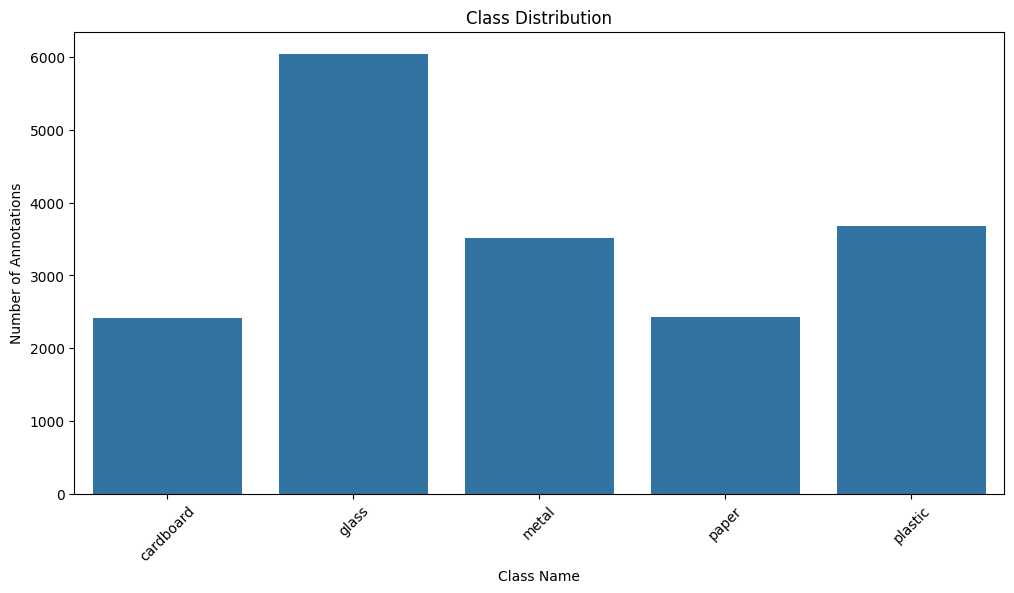

In [4]:
# Plot class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.xlabel("Class Name")
plt.ylabel("Number of Annotations")
plt.title("Class Distribution")
plt.show()

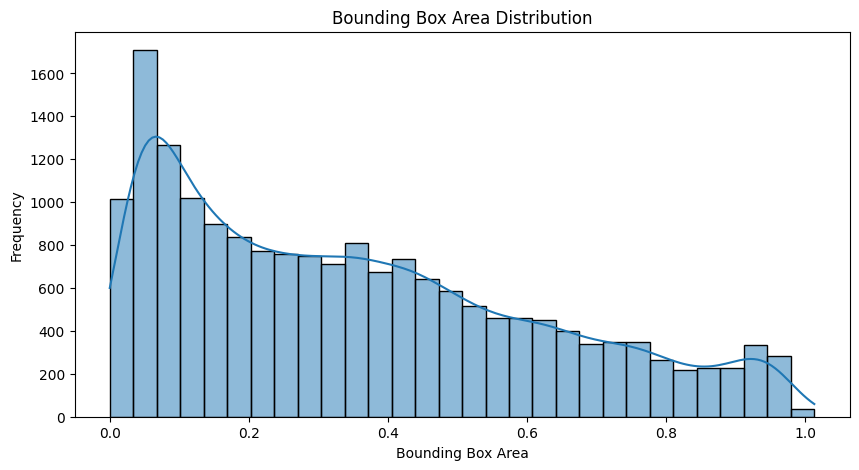

In [5]:
# Plot bounding box area distribution
plt.figure(figsize=(10, 5))
sns.histplot(bbox_areas, bins=30, kde=True)
plt.xlabel("Bounding Box Area")
plt.ylabel("Frequency")
plt.title("Bounding Box Area Distribution")
plt.show()

In [6]:
# Display sample images with annotations
def plot_sample_images(n=5):
    plt.figure(figsize=(15, 10))
    sample_classes = np.random.choice(class_folders, min(n, len(class_folders)), replace=False)

    for i, cls in enumerate(sample_classes):
        class_path = os.path.join(dataset_path, cls)
        image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        if not image_files:
            continue
        img_name = np.random.choice(image_files)
        img_path = os.path.join(class_path, img_name)
        label_path = os.path.join(class_path, os.path.splitext(img_name)[0] + ".txt")

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()
                h, w, _ = img.shape
                for line in lines:
                    class_id, x_center, y_center, bbox_w, bbox_h = map(float, line.strip().split())
                    x1 = int((x_center - bbox_w / 2) * w)
                    y1 = int((y_center - bbox_h / 2) * h)
                    x2 = int((x_center + bbox_w / 2) * w)
                    y2 = int((y_center + bbox_h / 2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                    cv2.putText(img, str(class_id), (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(cls)

    plt.show()

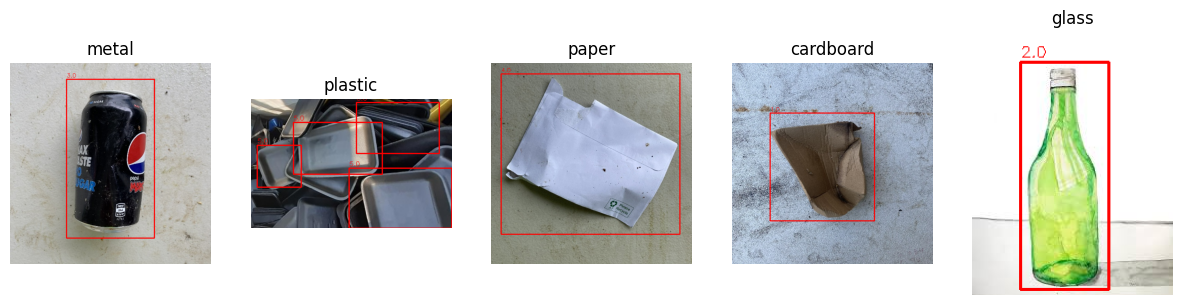

In [7]:
plot_sample_images()

In [8]:
import os
import cv2
import shutil
import random
from collections import defaultdict

# Paths
dataset_path = "/kaggle/input/datasets/sumn2u/recyclables"
output_path = "/kaggle/working/combined_dataset"

# Clean output directory
if os.path.exists(output_path):
    shutil.rmtree(output_path)
os.makedirs(output_path)

# --- STEP 1: Count original annotations per class ---
original_counts = defaultdict(int)
class_image_info = defaultdict(list)  # {class: [(img_file, annotation_count, label_path), ...]}

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    for img_file in images:
        label_file = os.path.join(class_path, os.path.splitext(img_file)[0] + ".txt")
        if not os.path.exists(label_file):
            continue

        with open(label_file, "r") as f:
            num_ann = len(f.readlines())
        original_counts[cls] += num_ann
        class_image_info[cls].append((img_file, num_ann, label_file))

print("Original annotation counts:")
for cls, count in original_counts.items():
    print(f"{cls}: {count}")

# --- STEP 2: Determine target (smallest class size) ---
target_instances = min(original_counts.values())
print(f"\nTarget annotations per class: {target_instances}")

# --- STEP 3: Undersample each class to reach target ---
final_counts = defaultdict(int)
missing_annotations = []

for cls, images_info in class_image_info.items():
    class_out_dir = os.path.join(output_path, cls)
    os.makedirs(class_out_dir, exist_ok=True)

    current_total = original_counts[cls]
    if current_total <= target_instances:
        # Copy all images and labels as they are
        for img_file, _, label_file in images_info:
            shutil.copy(os.path.join(dataset_path, cls, img_file), os.path.join(class_out_dir, img_file))
            shutil.copy(label_file, os.path.join(class_out_dir, os.path.basename(label_file)))
        final_counts[cls] = current_total
        continue

    # Need to remove excess annotations
    excess = current_total - target_instances
    print(f"\nClass '{cls}': {current_total} annotations → target {target_instances} (remove {excess})")

    # Randomly shuffle images
    random.shuffle(images_info)

    selected_images = []
    selected_ann_count = 0

    for img_file, num_ann, label_file in images_info:
        if selected_ann_count + num_ann <= target_instances:
            # Take whole image
            selected_images.append((img_file, num_ann, label_file, None))  # None = no trimming
            selected_ann_count += num_ann
        else:
            # Need only part of this image's annotations
            needed = target_instances - selected_ann_count
            if needed > 0:
                selected_images.append((img_file, needed, label_file, num_ann))  # store original count for trimming
                selected_ann_count += needed
            break  # target reached

    # Now copy selected images and (possibly trimmed) labels
    for img_file, keep_ann, label_file, original_ann_count in selected_images:
        src_img = os.path.join(dataset_path, cls, img_file)
        dst_img = os.path.join(class_out_dir, img_file)
        shutil.copy(src_img, dst_img)

        # Handle label file
        if original_ann_count is None:
            # Copy entire label file
            shutil.copy(label_file, os.path.join(class_out_dir, os.path.basename(label_file)))
        else:
            # Trim label file to keep only first 'keep_ann' lines
            with open(label_file, "r") as f_in:
                lines = f_in.readlines()
            with open(os.path.join(class_out_dir, os.path.basename(label_file)), "w") as f_out:
                f_out.writelines(lines[:keep_ann])

    final_counts[cls] = selected_ann_count

# --- SUMMARY ---
print("\n--- Final Balanced Dataset Counts ---")
for cls, count in final_counts.items():
    print(f"{cls}: {count}")

# Optional: report any missing annotations (images without label files)
print(f"\nMissing annotations (images without .txt): {len(missing_annotations)}")

Original annotation counts:
metal: 3521
glass: 6049
paper: 2422
cardboard: 2416
plastic: 3679

Target annotations per class: 2416

Class 'metal': 3521 annotations → target 2416 (remove 1105)

Class 'glass': 6049 annotations → target 2416 (remove 3633)

Class 'paper': 2422 annotations → target 2416 (remove 6)

Class 'plastic': 3679 annotations → target 2416 (remove 1263)

--- Final Balanced Dataset Counts ---
metal: 2416
glass: 2416
paper: 2416
cardboard: 2416
plastic: 2416

Missing annotations (images without .txt): 0


In [9]:
# import os
# import cv2
# import shutil
# import math
# import random
# import albumentations as A
# from collections import defaultdict
# import numpy as np

# # Paths
# dataset_path = "/kaggle/input/datasets/sumn2u/recyclables"
# output_path = "/kaggle/working/combined_dataset"

# # Clean output directory
# if os.path.exists(output_path):
#     shutil.rmtree(output_path)
# os.makedirs(output_path)

# # --- AUGMENTATION PIPELINE (lighter, realistic) ---
# core_transform = A.Compose([
#     A.HorizontalFlip(p=0.5),
#     A.RandomBrightnessContrast(p=0.3),
#     A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
#     A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.4),
#     A.MotionBlur(p=0.2),
#     A.CLAHE(p=0.2)  # better for low-light cases
# ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], min_visibility=0.3))

# # --- PRE-CALCULATE ORIGINAL COUNTS ---
# original_counts = defaultdict(int)
# for cls in os.listdir(dataset_path):
#     class_path = os.path.join(dataset_path, cls)
#     if not os.path.isdir(class_path):
#         continue
#     images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
#     for img_file in images:
#         label_file = os.path.join(class_path, os.path.splitext(img_file)[0] + ".txt")
#         if os.path.exists(label_file):
#             with open(label_file, "r") as f:
#                 original_counts[cls] += len(f.readlines())

# print("Original counts:")
# for cls, count in original_counts.items():
#     print(f"{cls}: {count}")

# # --- BALANCE STRATEGY ---
# min_class_size = min(original_counts.values())
# target_instances = {cls: min_class_size * 2 for cls in original_counts}
# print("\nTarget instances per class:")
# print(target_instances)

# # --- AUGMENTATION LOOP ---
# final_counts = defaultdict(int)
# missing_annotations, skipped_images = [], []

# for cls in os.listdir(dataset_path):
#     class_path = os.path.join(dataset_path, cls)
#     if not os.path.isdir(class_path):
#         continue

#     combined_class_path = os.path.join(output_path, cls)
#     os.makedirs(combined_class_path, exist_ok=True)

#     images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
#     current_instances = original_counts[cls]
#     target = target_instances[cls]

#     print(f"\nProcessing class '{cls}': {current_instances} → target {target}")

#     # Copy all originals first
#     for img_file in images:
#         shutil.copy(os.path.join(class_path, img_file), os.path.join(combined_class_path, img_file))
#         label_file = os.path.join(class_path, os.path.splitext(img_file)[0] + ".txt")
#         if os.path.exists(label_file):
#             shutil.copy(label_file, os.path.join(combined_class_path, os.path.splitext(img_file)[0] + ".txt"))
#         else:
#             missing_annotations.append(img_file)

#     # Only augment if needed
#     remaining = max(0, target - current_instances)
#     if remaining == 0:
#         final_counts[cls] = current_instances
#         continue

#     num_augmentations = math.ceil(remaining / current_instances)
#     random.shuffle(images)
#     augmented_added = 0

#     for img_file in images:
#         if augmented_added >= remaining:
#             break

#         img_path = os.path.join(class_path, img_file)
#         img = cv2.imread(img_path)
#         if img is None:
#             skipped_images.append(img_file)
#             continue
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         # Load bboxes
#         label_file = os.path.join(class_path, os.path.splitext(img_file)[0] + ".txt")
#         if not os.path.exists(label_file):
#             continue
#         bboxes, labels = [], []
#         with open(label_file, "r") as f:
#             for line in f:
#                 parts = line.strip().split()
#                 if len(parts) >= 5:
#                     cls_id = int(parts[0])
#                     bbox = list(map(float, parts[1:5]))
#                     if all(0 <= coord <= 1 for coord in bbox):
#                         bboxes.append(bbox)
#                         labels.append(cls_id)

#         if not bboxes:
#             skipped_images.append(img_file)
#             continue

#         # Apply augmentations
#         aug_count = 0
#         while aug_count < num_augmentations and augmented_added < remaining:
#             try:
#                 augmented = core_transform(image=img, bboxes=bboxes, class_labels=labels)
#                 if not augmented["bboxes"]:
#                     skipped_images.append(f"{img_file}_aug_{aug_count}")
#                     continue

#                 aug_img = cv2.cvtColor(augmented["image"], cv2.COLOR_RGB2BGR)
#                 aug_img_name = f"{os.path.splitext(img_file)[0]}_aug_{aug_count}.jpg"
#                 cv2.imwrite(os.path.join(combined_class_path, aug_img_name), aug_img)

#                 aug_label_name = f"{os.path.splitext(img_file)[0]}_aug_{aug_count}.txt"
#                 with open(os.path.join(combined_class_path, aug_label_name), "w") as f:
#                     for bbox, cls_id in zip(augmented["bboxes"], augmented["class_labels"]):
#                         f.write(f"{cls_id} {' '.join(map(str, bbox))}\n")

#                 augmented_added += len(augmented["bboxes"])
#                 aug_count += 1

#             except Exception as e:
#                 print(f"Error augmenting {img_file}: {e}")
#                 skipped_images.append(f"{img_file}_aug_{aug_count}")
#                 aug_count += 1
#                 continue

#     final_counts[cls] = current_instances + augmented_added

# # --- SUMMARY ---
# print("\n--- Final Dataset Counts ---")
# for cls, count in final_counts.items():
#     print(f"{cls}: {count}")

# print(f"\nMissing annotations: {len(missing_annotations)}")
# print(f"Skipped images: {len(skipped_images)}")
# if skipped_images:
#     print(f"Examples: {skipped_images[:10]}")

In [10]:
# --- COUNT FINAL IMAGES PER CLASS ---
print("\n--- Final Image Counts Per Class ---")

final_image_counts = {}

for cls in os.listdir(output_path):
    class_path = os.path.join(output_path, cls)
    
    if not os.path.isdir(class_path):
        continue

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    final_image_counts[cls] = len(image_files)

# Print results
for cls, count in final_image_counts.items():
    print(f"{cls}: {count} images")


--- Final Image Counts Per Class ---
paper: 1817 images
glass: 1555 images
plastic: 1726 images
cardboard: 2038 images
metal: 1860 images


In [11]:


# ==================== CONFIGURATION ====================
DATASET_PATH = "/kaggle/working/combined_dataset"

# Class mapping: folder name -> new class ID (starting from 0)
CLASS_MAPPING = {
    'cardboard': 0,
    'glass': 1,
    'metal': 2,
    'paper': 3,
    'plastic': 4
}
# Also handle possible plural names
CLASS_MAPPING.update({
    'metals': 2, 'cardboards': 0, 'glasses': 1, 'papers': 3, 'plastics': 4
})

# ==================== SAFETY BACKUP (optional) ====================
# Uncomment the next two lines to create a backup before cleaning
# backup_path = "/kaggle/working/combined_dataset_backup"
# shutil.copytree(DATASET_PATH, backup_path, dirs_exist_ok=True)

# ==================== CLEAN EACH CLASS FOLDER ====================
for folder_name in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue

    folder_lower = folder_name.lower()
    if folder_lower not in CLASS_MAPPING:
        print(f"Skipping unknown folder: {folder_name}")
        continue

    new_class_id = CLASS_MAPPING[folder_lower]
    print(f"\nProcessing '{folder_name}' → class ID {new_class_id}")

    # List all image files
    image_files = [f for f in os.listdir(folder_path)
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        txt_file = os.path.join(folder_path, base + '.txt')

        # If annotation missing → delete the image
        if not os.path.exists(txt_file):
            os.remove(os.path.join(folder_path, img_file))
            print(f"  Removed {img_file} (no .txt)")
            continue

        # Otherwise, update class IDs in the .txt file
        with open(txt_file, 'r') as f:
            lines = f.readlines()

        updated_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                parts[0] = str(new_class_id)   # replace class ID
                updated_lines.append(' '.join(parts) + '\n')
            # if line is malformed, drop it (or keep as is? I choose to drop)
        # Write back the corrected annotations
        with open(txt_file, 'w') as f:
            f.writelines(updated_lines)

    print(f"  Done. Remaining images: {len([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])}")

print("\n✅ In‑place cleaning complete.")
print("   - Images without .txt have been deleted.")
print("   - Class IDs inside all .txt files have been remapped (cardboard=0, glass=1, metal=2, paper=3, plastic=4).")


Processing 'paper' → class ID 3
  Done. Remaining images: 1817

Processing 'glass' → class ID 1
  Done. Remaining images: 1555

Processing 'plastic' → class ID 4
  Done. Remaining images: 1726

Processing 'cardboard' → class ID 0
  Done. Remaining images: 2038

Processing 'metal' → class ID 2
  Done. Remaining images: 1860

✅ In‑place cleaning complete.
   - Images without .txt have been deleted.
   - Class IDs inside all .txt files have been remapped (cardboard=0, glass=1, metal=2, paper=3, plastic=4).
